In [21]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
import pandas as pd

plt.rcParams['text.usetex'] = True

from utils import *

from tqdm.notebook import tqdm

## Model definition

In [22]:
N1 = 500
N2 = 500

N = N1+N2

DeltaE = 1

deltae = 0.5
lam = 5e-4

Nt = 300
dt = 10

In [23]:
gamma_1 = 2*np.pi*lam**2*N1/deltae
gamma_2 = 2*np.pi*lam**2*N2/deltae

gamma = gamma_1+gamma_2
print(gamma)

0.003141592653589793


## Simulation

In [24]:
ts = np.arange(Nt+1)*dt

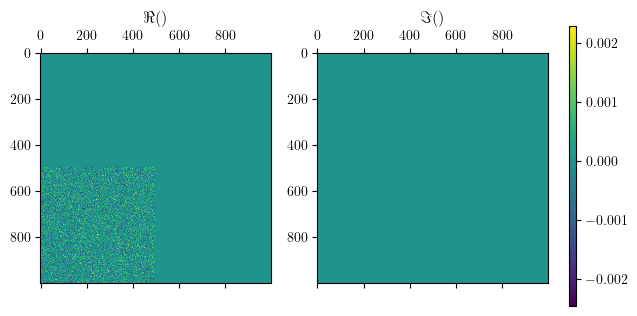

In [25]:
S0 = DeltaE*Z()
S1 = np.eye(2)
S2 = X()
S3 = Y()

E0 = np.eye(N)
E1 = np.zeros_like(E0)
E1[:N1,:N1] = np.diag((np.arange(N1)+1)*deltae/N1)
E1[N1:,N1:] = np.diag(DeltaE+(N1+np.arange(N2)+1)*deltae/N2)

B = np.zeros_like(E0)
B[N1:,:N1] = np.random.randn(N2*N1).reshape([N2,N1])
#B[:N1,N1:] = np.random.randn(N2*N1).reshape([N1,N2])
B = B*N1*N2/(np.sum(B**2))
B = lam*B

E2 = (B + B.H)/2
E3 = 1j*(B - B.H)/2

Es = [E0,E1,E2,E3]

plot_matrix(B)

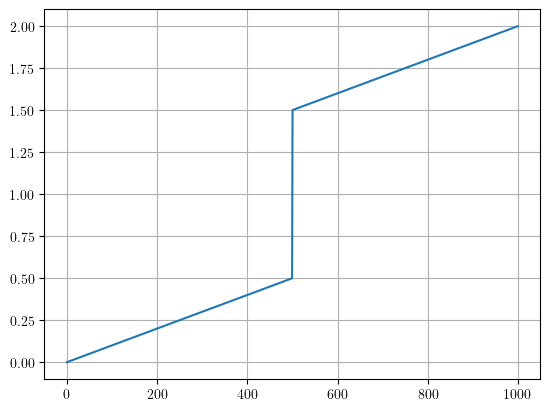

In [26]:
plt.figure()
plt.plot(np.diag(E1))
plt.grid()
plt.show()

In [27]:
# plot_matrix(np.kron(P(),B) + np.kron(M(),B.H))
# plot_matrix(np.kron(S2,E2) + np.kron(S3,E3))

In [28]:
# tmp = np.zeros([2*N,2*N])
# for n1 in range(N1):
#     for n2 in range(N2):
#         #tmp = tmp + np.random.randn()* (np.kron(P(),ket(n1,N)@bra(n2+N1,N)) + np.kron(P(),ket(n1,N)@bra(n2+N1,N)).H)
#         tmp = tmp + np.random.randn()* (np.kron(X(),ket(n1,N)@bra(n2+N1,N) + (ket(n1,N)@bra(n2+N1,N)).H))

# plot_matrix(tmp)
# plot_matrix(np.kron(S2,Es[2]) + np.kron(S3,Es[3]))

In [29]:
# H_int = np.kron(S2,E2) + np.kron(S3,E3)
# plot_matrix(H_int)

# print(np.all(np.round(H_int - H_int.H, decimals=12)==0))

# H_ = np.kron(X(),E2+E3)/2 + np.kron(Y(),1j*(E2-E3))/2
# plot_matrix(H_)

# print(np.all(np.round(H_int - H_, decimals=12)==0))

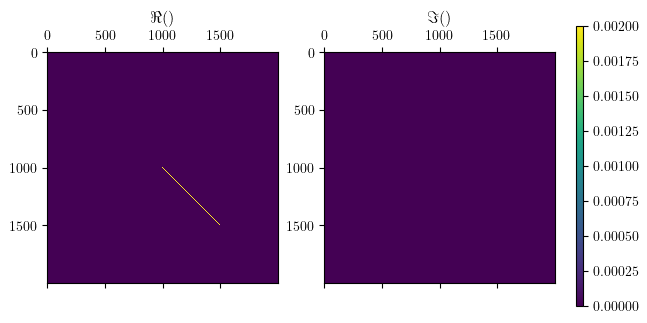

In [30]:
rhoS_0 = ketbra(1,1,2)
rhoE_0 = np.zeros([N,N])
rhoE_0[:N1,:N1] = np.eye(N1)/N1
plot_matrix(np.kron(rhoS_0,rhoE_0))

In [31]:
for E in Es:
    print(np.trace(rhoE_0@E))


1.0000000000000004
0.2505
0.0
0j


In [32]:
chi = np.zeros([len(Es),len(Es)])
for j in range(len(Es)):
    for k in range(len(Es)):
        chi[j,k] = np.real(np.trace(Es[j]@rhoE_0@Es[k]) - np.trace(Es[j]@rhoE_0)*np.trace(Es[k]@rhoE_0))

print(np.round(chi, decimals=12))
#print(np.round(np.linalg.eigvals(chi),decimals=12))


[[-0.00000e+00 -0.00000e+00  0.00000e+00  0.00000e+00]
 [-0.00000e+00  2.08333e-02  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  3.11261e-05  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  3.11261e-05]]


In [33]:
for E in Es:
    print(np.all(np.round(E-E.H,decimals=12)==0))


True
True
True
True


# Schrodinger simulation

In [34]:
#H_tot = np.kron(S0,Es[0]) + np.kron(S1,Es[1]) + np.kron(S2,Es[2]) + np.kron(S3,Es[3])

# U = sp.linalg.expm(-1j*H_tot*dt)

# print('Is U unitary? ', np.all(np.round(U.H@U-np.eye(2*N), decimals=12)==0))

# c = np.kron(ketbra(1,1,2), np.eye(N))

#plot_matrix(H_tot)

In [35]:
# sys_0 = ket(1,2)
# env_0 = np.zeros([N,1])
# env_0[:N1,:] = np.random.randn(N1).reshape([N1,1])
# env_0 = env_0 / np.sqrt((env_0.H@env_0)[0,0])
# x_0 = np.kron(sys_0,env_0)

# plot_matrix(x_0@x_0.H)
# print(x_0.H@x_0)

In [36]:
# tmp = np.zeros([2*N,2*N])
# numb = 100
# for j in range(numb):
#     sys_0 = ket(1,2)
#     env_0 = np.zeros([N,1])
#     env_0[:N1,:] = np.random.randn(N1).reshape([N1,1])
#     env_0 = env_0 / np.sqrt((env_0.H@env_0)[0,0])
#     x_0 = np.kron(sys_0,env_0)

#     tmp = tmp + x_0@x_0.H/numb

# plot_matrix(x_0@x_0.H)
# print(np.trace(tmp))

# def distance(rho,tau):
#     A = rho-tau
#     return np.real(np.trace(sp.linalg.sqrtm(A.H@A)))

# print(distance(x_0@x_0.H,rho_0))

In [37]:
# trajectories = []

# for j in tqdm(range(10)):
#     env_0 = np.zeros([N,1])
#     env_0[:N1,:] = np.random.randn(N1).reshape([N1,1])
#     env_0 = env_0 / np.sqrt((env_0.H@env_0)[0,0])
#     x_0 = np.kron(sys_0,env_0)

#     x_t = x_0

#     traj = [np.real((x_t.H@c@x_t)[0,0])]

#     for t in ts[:-1]:
#         x_t = U@x_t
#         traj.append(np.real((x_t.H@c@x_t)[0,0]))
#     traj = np.array(traj)
    
# trajectories.append(traj)

# avg_traj = np.average(np.array(trajectories),axis=0)

In [38]:
# s0 = ketbra(1,1,2)
# e0 = np.zeros([N,N])
# e0[:N1,:N1] = np.eye(N1)/N1
# rho_0 = np.kron(s0,e0)
# print(np.trace(rho_0))

# rho_t = rho_0

# true_traj = [np.real(np.trace(c@rho_t))]
# for t in tqdm(ts[:-1]):
#     rho_t = U @ rho_t @ U.H
#     true_traj.append(np.real(np.trace(c@rho_t)))

# true_traj = np.array(true_traj)

In [39]:
Lc_D = Lindblad_to_matrix(Z()*0,[S2])


def fun(t,x):
    xdot = t*chi[2,2]* Lc_D  @ x 
    return xdot

result = sp.integrate.solve_ivp(fun,[0,(Nt+1)*dt], vec(ketbra(1,1,2)).reshape([4,]), t_eval=ts)

print('done')

rho_Ss = []
for j in range(result.y.shape[1]):
    rho_Ss.append(unvec(result.y[:,j].reshape([4,])))
rho_Ss = np.array(rho_Ss)

ys = np.real(np.trace(rho_Ss@ketbra(1,1,2),axis1=1,axis2=2))


done


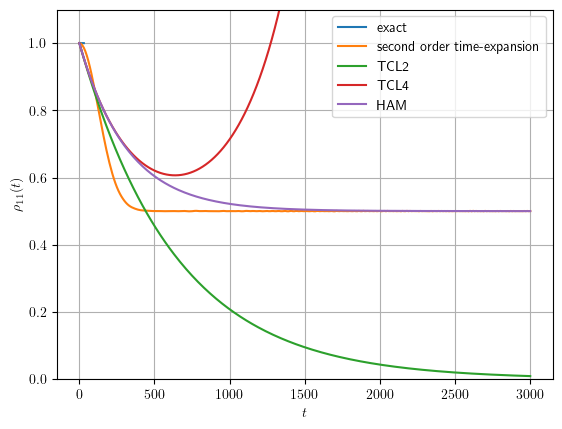

In [40]:
df = pd.read_csv('../highly_non_markovian_exact.csv')

plt.figure()
plt.plot(df['t'],df['y'], label='exact')
plt.plot(ts,ys, label='second order time-expansion')
plt.plot(ts,np.exp(-gamma_2*ts),label='TCL2')
plt.plot(ts,np.exp(-gamma_2*ts+gamma_1*gamma_2*ts**2/2),label='TCL4')
plt.plot(ts,gamma_1/gamma + gamma_2/gamma * np.exp(-gamma*ts),label='HAM')
plt.grid()
plt.ylabel(r'$\rho_{11}(t)$')
plt.xlabel('$t$')
plt.ylim([0,1.1])
plt.legend()
plt.show()